# Praktikum Pengolahan Citra
## JOB MINGGU 01: DASAR BERKAS GAMBAR (CITRA)
**Nama:** Intan Nurul Faizia  
**NIM:** 3.34.23.2.11

**Dosen Pengampu:** Ir. Prayitno, S.ST., M.T., Ph.D.  
**Program Studi:** STR Teknologi Rekayasa Komputer  
**Politeknik Negeri Semarang**

---
## P1. Mendefinisikan Istilah bit, byte, kilobyte, megabyte dll pada citra

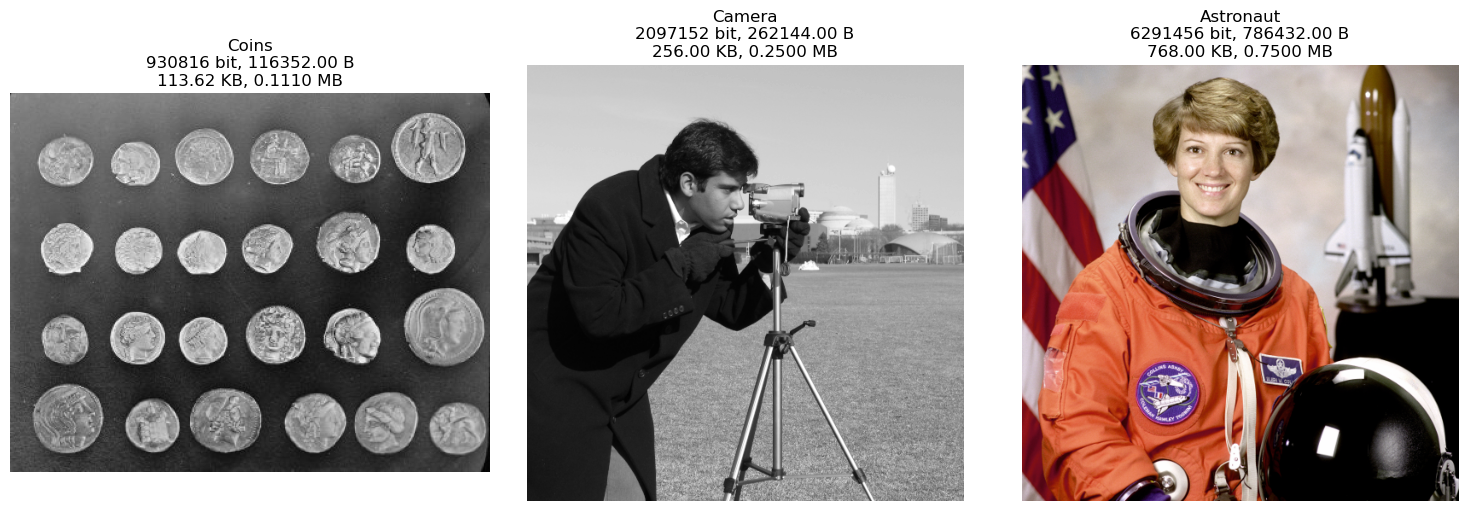

Coins: 930816 bit | 116352 Bytes | 113.62 KB | 0.1110 MB
Camera: 2097152 bit | 262144 Bytes | 256.00 KB | 0.2500 MB
Astronaut: 6291456 bit | 786432 Bytes | 768.00 KB | 0.7500 MB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Contoh gambar dari scikit-image
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Fungsi untuk menghitung ukuran gambar dalam bit, byte, KB, MB
def hitung_ukuran(image):
    bit_per_pixel = 8 if len(image.shape) == 2 else 24  # Grayscale = 8 bit, RGB = 24 bit
    total_pixels = image.shape[0] * image.shape[1]
    total_bits = total_pixels * bit_per_pixel
    total_bytes = total_bits / 8
    total_kb = total_bytes / 1024
    total_mb = total_kb / 1024
    return total_bits, total_bytes, total_kb, total_mb

# Menyusun gambar dan ukurannya dalam satu baris
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Daftar gambar dan nama
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    bits, bytes_, kb, mb = hitung_ukuran(img)
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\n{bits} bit, {bytes_:.2f} B\n{kb:.2f} KB, {mb:.4f} MB")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Cetak ringkasan
for img, nama in zip(gambar_list, nama_list):
    bits, bytes_, kb, mb = hitung_ukuran(img)
    print(f"{nama}: {bits} bit | {bytes_:.0f} Bytes | {kb:.2f} KB | {mb:.4f} MB")

---
## P2. Citra digital tersusun dari beberapa pixel

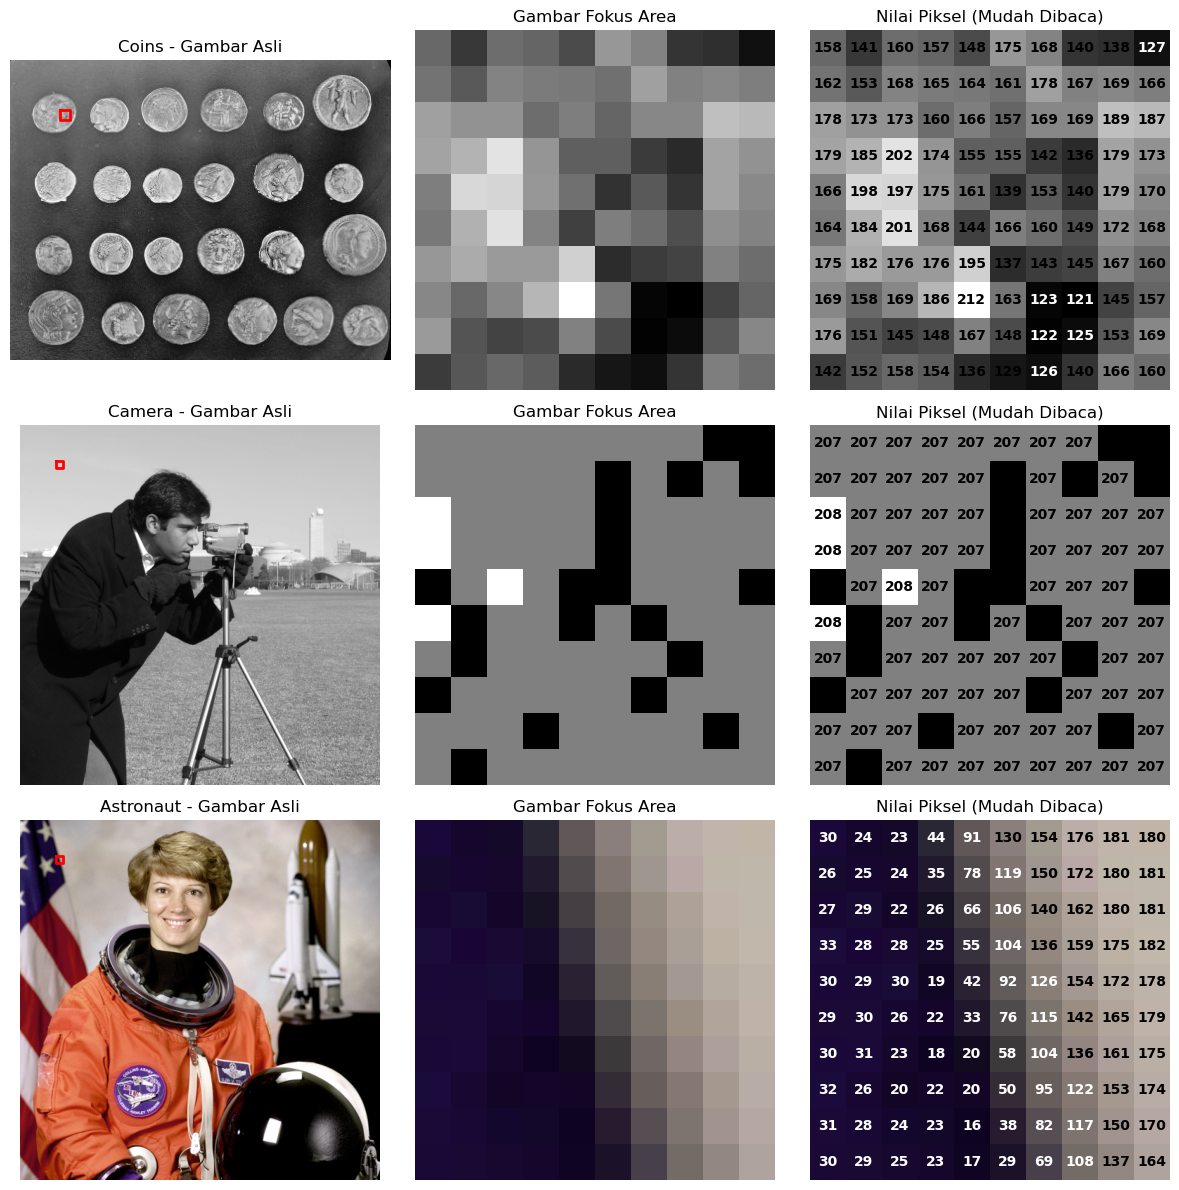

In [2]:
# Menampilkan bagaimana citra digital tersusun dari piksel dengan area fokus yang ditandai

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# List gambar dan nama
gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

# Koordinat area kecil yang di-zoom
x_start, x_end = 50, 60
y_start, y_end = 50, 60

for i, (img, nama) in enumerate(zip(gambar_list, nama_list)):
    # Gambar asli
    axes[i, 0].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    axes[i, 0].set_title(f"{nama} - Gambar Asli")
    axes[i, 0].axis('off')

    # Tambahkan kotak merah untuk menunjukkan area yang difokuskan
    rect_x = [x_start, x_end, x_end, x_start, x_start]
    rect_y = [y_start, y_start, y_end, y_end, y_start]
    axes[i, 0].plot(rect_x, rect_y, color="red", linewidth=2)

    # Gambar fokus area
    zoomed_img = img[y_start:y_end, x_start:x_end]
    axes[i, 1].imshow(zoomed_img, cmap='gray' if len(img.shape) == 2 else None, interpolation='nearest')
    axes[i, 1].set_title("Gambar Fokus Area")
    axes[i, 1].axis('off')

    # Menampilkan nilai piksel dalam area yang di-zoom (khusus RGB, gunakan rata-rata kanal)
    axes[i, 2].imshow(zoomed_img, cmap='gray' if len(img.shape) == 2 else None, interpolation='nearest')

    for y in range(zoomed_img.shape[0]):
        for x in range(zoomed_img.shape[1]):
            if len(img.shape) == 3:  # Jika RGB, ambil nilai rata-rata piksel untuk tampilan angka
                pixel_value = np.mean(zoomed_img[y, x]).astype(int)
            else:
                pixel_value = zoomed_img[y, x]

            # Pilih warna teks agar mudah dibaca di latar belakang
            text_color = "white" if pixel_value < 128 else "black"
            axes[i, 2].text(x, y, str(pixel_value), color=text_color,
                            ha='center', va='center', fontsize=10, fontweight='bold')

    axes[i, 2].set_title("Nilai Piksel (Mudah Dibaca)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

---
## P3. Citra disimpan dalam Array


=== Coins ===
Tipe Data: <class 'numpy.ndarray'>
Dimensi: (303, 384)
Tipe Nilai Piksel: uint8
Contoh nilai piksel (5x5 pertama):
[[ 47 123 133 129 137]
 [ 93 144 145 143 145]
 [126 147 143 147 145]
 [131 136 133 139 136]
 [131 133 134 135 129]]

=== Camera ===
Tipe Data: <class 'numpy.ndarray'>
Dimensi: (512, 512)
Tipe Nilai Piksel: uint8
Contoh nilai piksel (5x5 pertama):
[[200 200 200 200 199]
 [200 199 199 200 199]
 [199 199 199 200 200]
 [200 200 199 199 199]
 [200 200 200 200 199]]

=== Astronaut ===
Tipe Data: <class 'numpy.ndarray'>
Dimensi: (512, 512, 3)
Tipe Nilai Piksel: uint8
Contoh nilai piksel (5x5 pertama):
[[[154 147 151]
  [109 103 124]
  [ 63  58 102]
  [ 54  51  98]
  [ 76  76 106]]

 [[177 171 171]
  [144 141 143]
  [113 114 124]
  [106 107 120]
  [128 128 131]]

 [[201 194 193]
  [182 178 175]
  [168 165 164]
  [159 157 157]
  [167 165 161]]

 [[220 213 210]
  [214 206 206]
  [202 198 196]
  [197 191 193]
  [200 194 196]]

 [[232 223 223]
  [226 220 215]
  [221 215

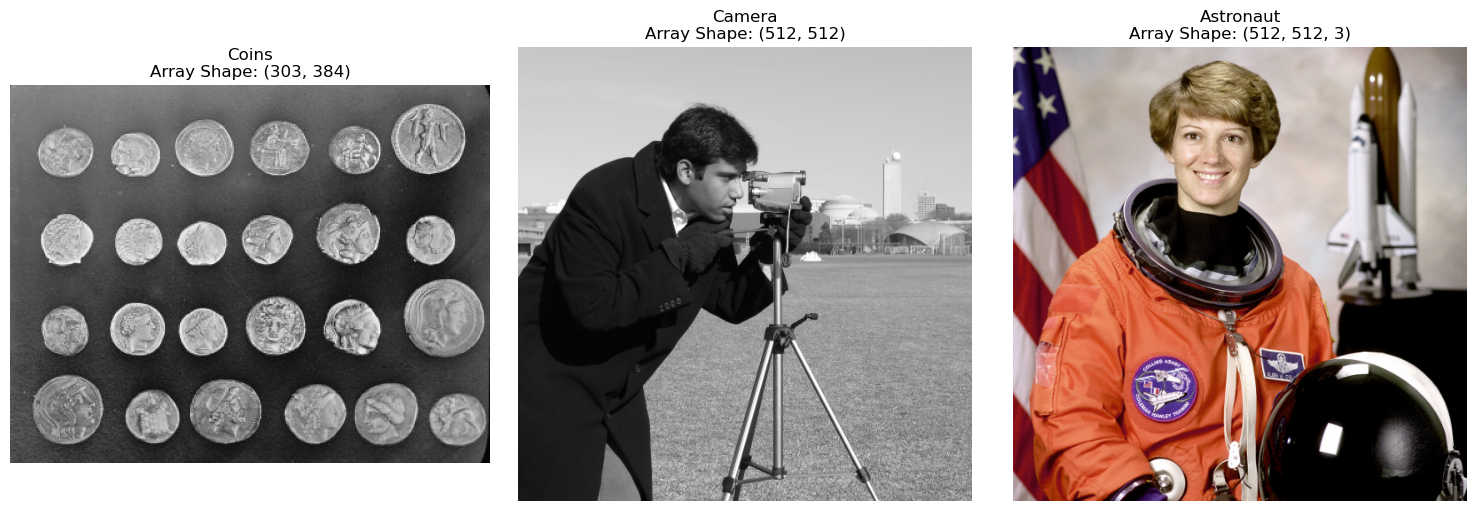

In [3]:
# Menjelaskan bagaimana citra disimpan dalam array NumPy

import numpy as np

# Memuat gambar dari scikit-image
gambar_coins = data.coins()
gambar_camera = data.camera()
gambar_astronaut = data.astronaut()

# Fungsi untuk menampilkan informasi array NumPy dari gambar
def info_array_numpy(image, nama):
    print(f"\n=== {nama} ===")
    print(f"Tipe Data: {type(image)}")  # Harusnya <class 'numpy.ndarray'>
    print(f"Dimensi: {image.shape}")  # Menampilkan dimensi gambar (height, width, channels jika RGB)
    print(f"Tipe Nilai Piksel: {image.dtype}")  # Menampilkan tipe data dalam array (uint8)

    # Menampilkan sebagian kecil dari array (5x5 piksel pertama)
    print("Contoh nilai piksel (5x5 pertama):")
    print(image[:5, :5] if len(image.shape) == 2 else image[:5, :5, :])

# Menampilkan informasi setiap gambar
info_array_numpy(gambar_coins, "Coins")
info_array_numpy(gambar_camera, "Camera")
info_array_numpy(gambar_astronaut, "Astronaut")

# Visualisasi bagaimana array NumPy mewakili citra
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gambar_list = [gambar_coins, gambar_camera, gambar_astronaut]
nama_list = ["Coins", "Camera", "Astronaut"]

for ax, img, nama in zip(axes, gambar_list, nama_list):
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(f"{nama}\nArray Shape: {img.shape}")
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## P4. Sistem Koordinat Kiri Atas Dalam Citra Digital

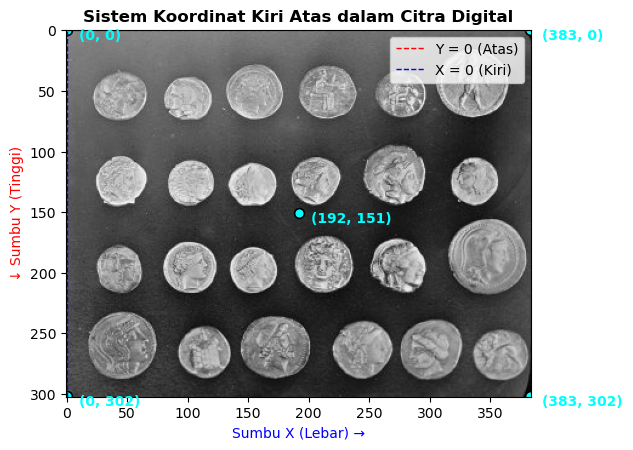

In [4]:
# Menjelaskan sistem koordinat kiri atas dalam citra digital dengan warna anotasi yang lebih kontras

# Pilih salah satu gambar untuk contoh koordinat
gambar_sample = data.coins()

# Ukuran gambar
height, width = gambar_sample.shape

# Buat plot
fig, ax = plt.subplots(figsize=(6, 6))

# Tampilkan gambar
ax.imshow(gambar_sample, cmap='gray')

# Tambahkan anotasi sumbu koordinat
ax.set_title("Sistem Koordinat Kiri Atas dalam Citra Digital", fontsize=12, fontweight="bold")
ax.set_xlabel("Sumbu X (Lebar) →", fontsize=10, color="blue")
ax.set_ylabel("↓ Sumbu Y (Tinggi)", fontsize=10, color="red")

# Tambahkan garis koordinat utama
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label="Y = 0 (Atas)")
ax.axvline(x=0, color='blue', linestyle='--', linewidth=1, label="X = 0 (Kiri)")

# Tambahkan beberapa titik koordinat penting dengan warna kontras (cyan)
koordinat_titik = [(0, 0), (width-1, 0), (0, height-1), (width-1, height-1), (width//2, height//2)]
for x, y in koordinat_titik:
    ax.scatter(x, y, color='cyan', s=50, edgecolors='black', linewidth=1.2)  # Titik dengan outline hitam
    ax.text(x + 10, y + 10, f"({x}, {y})", color="cyan", fontsize=10,
            fontweight="bold", ha="left", va="bottom")

# Tambahkan legenda
ax.legend(loc="upper right")

plt.show()

---
## P5. Warna RGB dalam citra digital

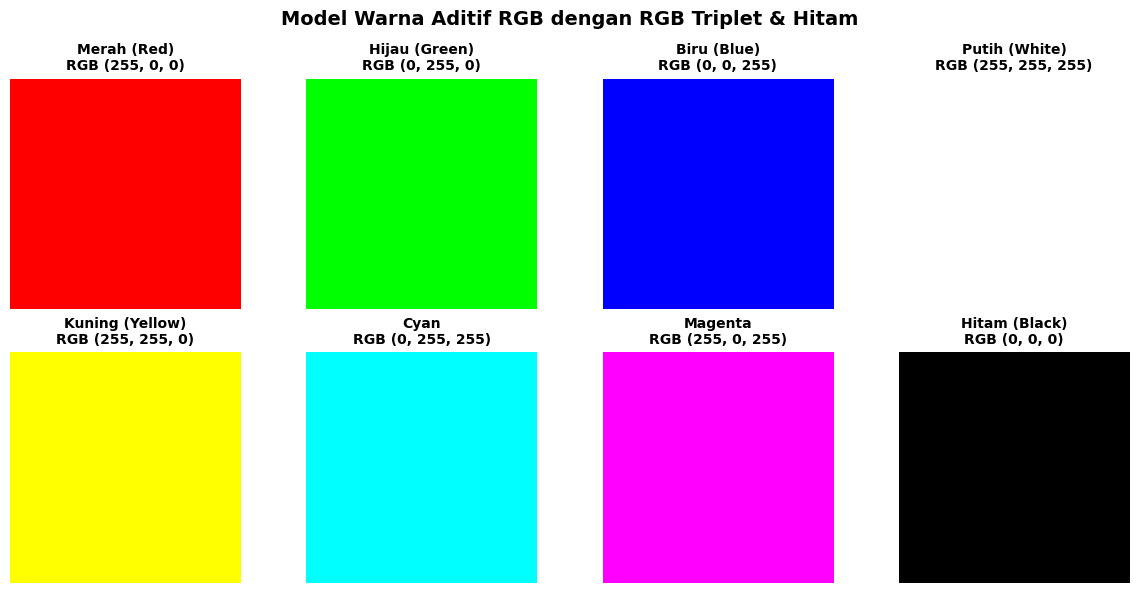

In [5]:
# Menjelaskan model warna aditif RGB dalam citra digital dengan RGB Triplet dan warna hitam

# Membuat tiga kanal warna utama dalam model RGB
red_channel = np.zeros((100, 100, 3), dtype=np.uint8)
green_channel = np.zeros((100, 100, 3), dtype=np.uint8)
blue_channel = np.zeros((100, 100, 3), dtype=np.uint8)

# Mengatur warna merah, hijau, dan biru murni
red_channel[:, :, 0] = 255    # (255, 0, 0) - Merah
green_channel[:, :, 1] = 255  # (0, 255, 0) - Hijau
blue_channel[:, :, 2] = 255   # (0, 0, 255) - Biru

# Membuat kombinasi warna dari RGB
yellow  = red_channel + green_channel                    # (255, 255, 0) - Kuning
cyan    = green_channel + blue_channel                   # (0, 255, 255) - Cyan
magenta = red_channel + blue_channel                     # (255, 0, 255) - Magenta
white   = red_channel + green_channel + blue_channel     # (255, 255, 255) - Putih
black   = np.zeros((100, 100, 3), dtype=np.uint8)        # (0, 0, 0) - Hitam

# Menampilkan hasil dengan RGB Triplet
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# List gambar, nama warna, dan RGB triplet
color_list  = [red_channel, green_channel, blue_channel, white, yellow, cyan, magenta, black]
color_names = ["Merah (Red)", "Hijau (Green)", "Biru (Blue)", "Putih (White)",
               "Kuning (Yellow)", "Cyan", "Magenta", "Hitam (Black)"]
rgb_values  = ["(255, 0, 0)", "(0, 255, 0)", "(0, 0, 255)", "(255, 255, 255)",
               "(255, 255, 0)", "(0, 255, 255)", "(255, 0, 255)", "(0, 0, 0)"]

# Plot warna primer, hasil campuran, dan hitam dengan RGB triplet
for ax, color, name, rgb in zip(axes.flat, color_list, color_names, rgb_values):
    ax.imshow(color)
    ax.set_title(f"{name}\nRGB {rgb}", fontsize=10, fontweight="bold")
    ax.axis('off')

plt.suptitle("Model Warna Aditif RGB dengan RGB Triplet & Hitam", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## P6. Urutan tiga nilai warna dalam citra scikit-image

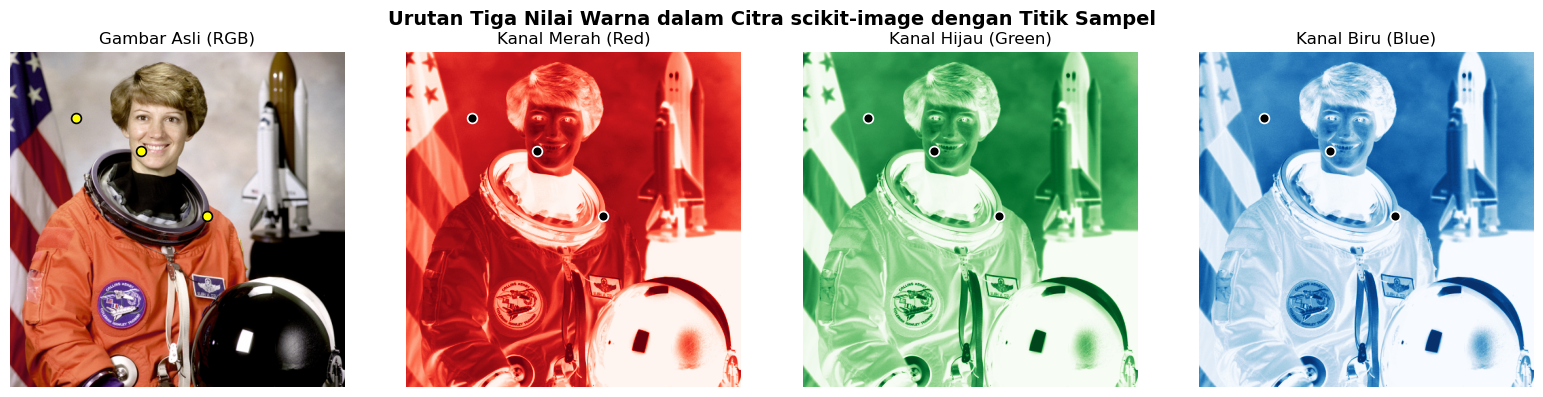

Nilai RGB pada titik koordinat yang dipilih:
Titik 1 - Koordinat (100, 100):
  Red   (Merah) : 187
  Green (Hijau) : 176
  Blue  (Biru)  : 169
  RGB Triplet   : (187, 176, 169)

Titik 2 - Koordinat (200, 150):
  Red   (Merah) : 236
  Green (Hijau) : 210
  Blue  (Biru)  : 184
  RGB Triplet   : (236, 210, 184)

Titik 3 - Koordinat (300, 250):
  Red   (Merah) : 96
  Green (Hijau) : 76
  Blue  (Biru)  : 93
  RGB Triplet   : (96, 76, 93)



In [6]:
# Menjelaskan urutan tiga nilai warna dalam citra scikit-image dengan titik penanda koordinat piksel

# Memuat gambar RGB dari scikit-image
gambar_rgb = data.astronaut()  # Gambar astronaut dalam format RGB

# Ekstrak tiga kanal warna (R, G, B)
red_channel   = gambar_rgb[:, :, 0]  # Kanal merah
green_channel = gambar_rgb[:, :, 1]  # Kanal hijau
blue_channel  = gambar_rgb[:, :, 2]  # Kanal biru

# Koordinat tiga titik sampel untuk menampilkan nilai piksel RGB
titik_koordinat = [(100, 100), (200, 150), (300, 250)]

# Menampilkan gambar asli dan masing-masing kanal warna
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Tampilkan gambar asli dengan titik penanda
axes[0].imshow(gambar_rgb)
axes[0].set_title("Gambar Asli (RGB)")
for x, y in titik_koordinat:
    axes[0].scatter(x, y, color='yellow', s=50, edgecolors='black', linewidth=1.2)

# Tampilkan kanal merah dengan titik
axes[1].imshow(red_channel, cmap="Reds")
axes[1].set_title("Kanal Merah (Red)")
for x, y in titik_koordinat:
    axes[1].scatter(x, y, color='black', s=50, edgecolors='white', linewidth=1.2)

# Tampilkan kanal hijau dengan titik
axes[2].imshow(green_channel, cmap="Greens")
axes[2].set_title("Kanal Hijau (Green)")
for x, y in titik_koordinat:
    axes[2].scatter(x, y, color='black', s=50, edgecolors='white', linewidth=1.2)

# Tampilkan kanal biru dengan titik
axes[3].imshow(blue_channel, cmap="Blues")
axes[3].set_title("Kanal Biru (Blue)")
for x, y in titik_koordinat:
    axes[3].scatter(x, y, color='black', s=50, edgecolors='white', linewidth=1.2)

# Hilangkan sumbu koordinat
for ax in axes:
    ax.axis("off")

plt.suptitle("Urutan Tiga Nilai Warna dalam Citra scikit-image dengan Titik Sampel",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Menampilkan contoh nilai piksel untuk titik-titik yang dipilih
print("Nilai RGB pada titik koordinat yang dipilih:")
for i, (x, y) in enumerate(titik_koordinat):
    r_val, g_val, b_val = gambar_rgb[y, x, 0], gambar_rgb[y, x, 1], gambar_rgb[y, x, 2]
    print(f"Titik {i+1} - Koordinat ({x}, {y}):")
    print(f"  Red   (Merah) : {r_val}")
    print(f"  Green (Hijau) : {g_val}")
    print(f"  Blue  (Biru)  : {b_val}")
    print(f"  RGB Triplet   : ({r_val}, {g_val}, {b_val})\n")

---
## P7. Karakteristik format citra BMP, JPEG, dan TIFF

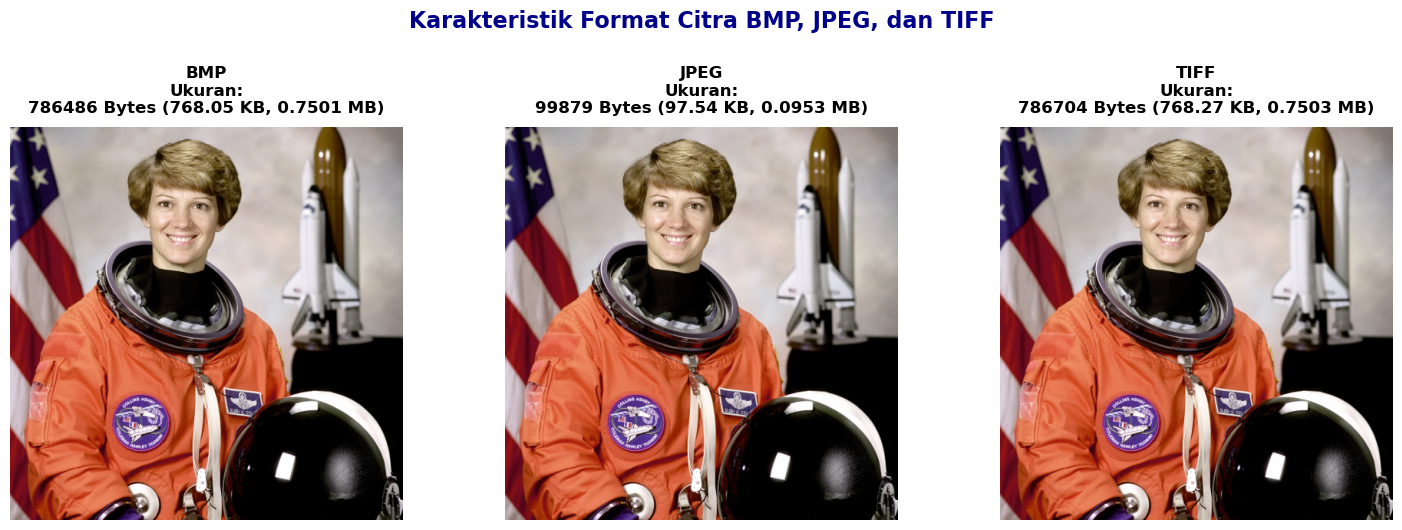

Karakteristik Format Citra:

1. BMP (Bitmap):
- Format tidak terkompresi, menghasilkan ukuran file yang besar.
- Kualitas gambar sangat baik, tidak ada kehilangan data.
- Cocok untuk pengolahan citra yang memerlukan ketelitian tinggi.
- Ukuran file: 786486 Bytes (768.05 KB, 0.7501 MB)

2. JPEG (Joint Photographic Experts Group):
- Format terkompresi dengan metode lossy (menghilangkan sebagian data).
- Ukuran file lebih kecil dibanding BMP dan TIFF.
- Cocok untuk fotografi, media sosial, dan tampilan web.
- Ukuran file: 99879 Bytes (97.54 KB, 0.0953 MB)

3. TIFF (Tagged Image File Format):
- Format fleksibel yang mendukung kompresi lossy atau lossless.
- Digunakan dalam pencetakan profesional dan pemrosesan citra medis.
- Ukuran file bisa besar tergantung tingkat kompresi yang digunakan.
- Ukuran file: 786704 Bytes (768.27 KB, 0.7503 MB)


In [7]:
from skimage import io
import os

# Membuat citra contoh dari skimage
gambar = data.astronaut()

# Simpan gambar dalam format BMP, JPEG, dan TIFF
io.imsave("astronaut.bmp", gambar)
io.imsave("astronaut.jpg", gambar, quality=95)  # JPEG menggunakan parameter quality
io.imsave("astronaut.tiff", gambar)

# Fungsi untuk menghitung ukuran file
def ukuran_file(nama_file):
    size_bytes = os.path.getsize(nama_file)
    size_kb = size_bytes / 1024
    size_mb = size_kb / 1024
    return f"{size_bytes} Bytes ({size_kb:.2f} KB, {size_mb:.4f} MB)"

# Menampilkan informasi ukuran file dari masing-masing format
format_citra = ["BMP", "JPEG", "TIFF"]
nama_file    = ["astronaut.bmp", "astronaut.jpg", "astronaut.tiff"]
ukuran       = [ukuran_file(file) for file in nama_file]

# Tampilkan gambar dan informasi karakteristik format citra
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fmt, file in zip(axes, format_citra, nama_file):
    img = io.imread(file)
    ax.imshow(img)
    ax.set_title(f"{fmt}\nUkuran:\n{ukuran_file(file)}", fontsize=12,
                 fontweight="bold", color="black", pad=10)
    ax.axis("off")

plt.suptitle("Karakteristik Format Citra BMP, JPEG, dan TIFF",
             fontsize=16, fontweight="bold", color="darkblue", y=1.05)
plt.tight_layout()
plt.show()

# Menampilkan informasi karakteristik format citra
print("Karakteristik Format Citra:")
print("\n1. BMP (Bitmap):")
print("- Format tidak terkompresi, menghasilkan ukuran file yang besar.")
print("- Kualitas gambar sangat baik, tidak ada kehilangan data.")
print("- Cocok untuk pengolahan citra yang memerlukan ketelitian tinggi.")
print(f"- Ukuran file: {ukuran[0]}")

print("\n2. JPEG (Joint Photographic Experts Group):")
print("- Format terkompresi dengan metode lossy (menghilangkan sebagian data).")
print("- Ukuran file lebih kecil dibanding BMP dan TIFF.")
print("- Cocok untuk fotografi, media sosial, dan tampilan web.")
print(f"- Ukuran file: {ukuran[1]}")

print("\n3. TIFF (Tagged Image File Format):")
print("- Format fleksibel yang mendukung kompresi lossy atau lossless.")
print("- Digunakan dalam pencetakan profesional dan pemrosesan citra medis.")
print("- Ukuran file bisa besar tergantung tingkat kompresi yang digunakan.")
print(f"- Ukuran file: {ukuran[2]}")

---
## P8. Perbedaan kompresi lossy dan lossless

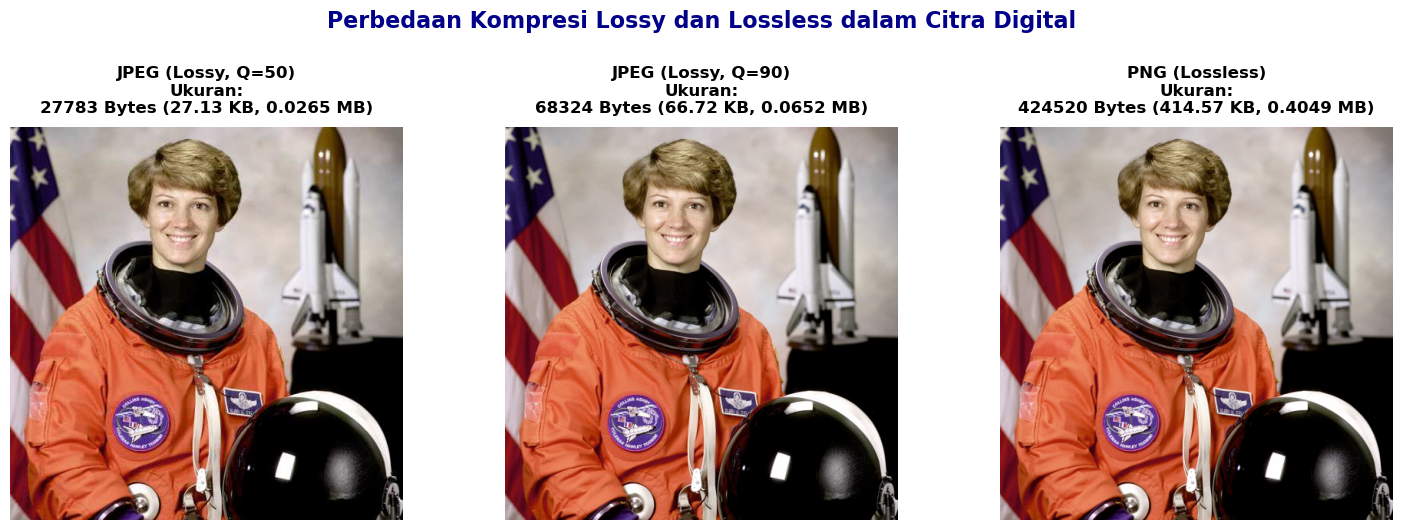

Perbedaan Kompresi Lossy dan Lossless:

1. JPEG (Lossy, Quality=50):
- Menggunakan kompresi lossy dengan kualitas rendah (Q=50).
- Detail gambar berkurang, muncul artefak kompresi.
- Ukuran file lebih kecil.
- Ukuran file: 27783 Bytes (27.13 KB, 0.0265 MB)

2. JPEG (Lossy, Quality=90):
- Menggunakan kompresi lossy dengan kualitas lebih tinggi (Q=90).
- Detail gambar masih cukup baik, artefak lebih sedikit.
- Ukuran file lebih besar dibanding Q=50, tetapi lebih kecil dibanding lossless.
- Ukuran file: 68324 Bytes (66.72 KB, 0.0652 MB)

3. PNG (Lossless):
- Menggunakan kompresi lossless, tidak ada kehilangan data.
- Detail gambar tetap sempurna seperti aslinya.
- Ukuran file lebih besar dibanding JPEG lossy.
- Ukuran file: 424520 Bytes (414.57 KB, 0.4049 MB)


In [8]:
# Menjelaskan perbedaan kompresi lossy dan lossless dalam citra digital

# Simpan gambar dalam format lossy (JPEG) dan lossless (PNG)
jpeg_quality_50 = "astronaut_lossy_50.jpg"
jpeg_quality_90 = "astronaut_lossy_90.jpg"
png_lossless    = "astronaut_lossless.png"

io.imsave(jpeg_quality_50, gambar, quality=50)  # JPEG lossy dengan kualitas rendah
io.imsave(jpeg_quality_90, gambar, quality=90)  # JPEG lossy dengan kualitas tinggi
io.imsave(png_lossless, gambar)                 # PNG lossless

# Menampilkan ukuran file dari masing-masing format
nama_file_kompresi = [jpeg_quality_50, jpeg_quality_90, png_lossless]
ukuran_kompresi    = [ukuran_file(file) for file in nama_file_kompresi]

# Menampilkan gambar hasil kompresi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

kompresi_label = ["JPEG (Lossy, Q=50)", "JPEG (Lossy, Q=90)", "PNG (Lossless)"]

for ax, file, label in zip(axes, nama_file_kompresi, kompresi_label):
    img = io.imread(file)
    ax.imshow(img)
    ax.set_title(f"{label}\nUkuran:\n{ukuran_file(file)}", fontsize=12,
                 fontweight="bold", color="black", pad=10)
    ax.axis("off")

plt.suptitle("Perbedaan Kompresi Lossy dan Lossless dalam Citra Digital",
             fontsize=16, fontweight="bold", color="darkblue", y=1.05)
plt.tight_layout()
plt.show()

# Menampilkan informasi perbedaan kompresi dalam teks
print("Perbedaan Kompresi Lossy dan Lossless:")

print("\n1. JPEG (Lossy, Quality=50):")
print("- Menggunakan kompresi lossy dengan kualitas rendah (Q=50).")
print("- Detail gambar berkurang, muncul artefak kompresi.")
print("- Ukuran file lebih kecil.")
print(f"- Ukuran file: {ukuran_kompresi[0]}")

print("\n2. JPEG (Lossy, Quality=90):")
print("- Menggunakan kompresi lossy dengan kualitas lebih tinggi (Q=90).")
print("- Detail gambar masih cukup baik, artefak lebih sedikit.")
print("- Ukuran file lebih besar dibanding Q=50, tetapi lebih kecil dibanding lossless.")
print(f"- Ukuran file: {ukuran_kompresi[1]}")

print("\n3. PNG (Lossless):")
print("- Menggunakan kompresi lossless, tidak ada kehilangan data.")
print("- Detail gambar tetap sempurna seperti aslinya.")
print("- Ukuran file lebih besar dibanding JPEG lossy.")
print(f"- Ukuran file: {ukuran_kompresi[2]}")

---
## F. Penugasan — Jawaban No. 3

### Manfaat Mempelajari P1 sampai P8 dalam Membuat Aplikasi atau Penelitian Terapan

Mempelajari praktikum P1 hingga P8 memberikan fondasi yang sangat kuat dalam bidang pengolahan citra digital yang dapat diterapkan langsung pada berbagai skenario pengembangan aplikasi dan penelitian terapan.

**P1 – Dasar Bit, Byte, dan Ukuran Citra:**  
Pemahaman ini penting saat merancang sistem yang memerlukan efisiensi memori, misalnya pada aplikasi kamera mobile atau sistem penyimpanan citra medis. Dengan mengetahui ukuran file secara presisi, pengembang dapat mengoptimalkan alokasi memori dan bandwidth jaringan.

**P2 – Citra Tersusun dari Piksel:**  
Konsep piksel menjadi dasar algoritma deteksi objek dan segmentasi citra pada aplikasi seperti pengenalan plat nomor kendaraan, sistem absensi wajah, atau inspeksi kualitas produk pada industri manufaktur.

**P3 – Representasi Array NumPy:**  
Penyimpanan citra sebagai array NumPy memungkinkan manipulasi matematis yang cepat dan efisien. Hal ini sangat berguna dalam penelitian Computer Vision berbasis deep learning, di mana preprocessing data citra dilakukan dalam bentuk array sebelum dimasukkan ke model jaringan saraf tiruan.

**P4 – Sistem Koordinat Kiri Atas:**  
Pemahaman sistem koordinat ini krusial dalam pengembangan aplikasi augmented reality (AR), robot vision, dan sistem navigasi otonom, di mana penentuan posisi objek secara akurat dalam frame gambar sangat dibutuhkan.

**P5 – Model Warna RGB:**  
Penguasaan model RGB memungkinkan pengembang membangun fitur filter warna pada aplikasi pengeditan foto, sistem deteksi warna pada robot industri, atau analisis vegetasi menggunakan citra satelit (indeks NDVI).

**P6 – Urutan Nilai Warna dalam scikit-image:**  
Memahami urutan kanal (R, G, B) sangat penting agar tidak terjadi kesalahan interpretasi warna, terutama saat menggabungkan beberapa library (misalnya OpenCV menggunakan urutan BGR). Ini krusial dalam penelitian analisis citra medis seperti deteksi sel darah atau jaringan tumor.

**P7 – Karakteristik Format BMP, JPEG, TIFF:**  
Pemilihan format citra yang tepat berdampak langsung pada kualitas dan efisiensi sistem. Misalnya, menggunakan TIFF untuk penyimpanan citra hasil pemindaian patologi, sementara JPEG digunakan untuk tampilan thumbnail pada antarmuka web.

**P8 – Kompresi Lossy dan Lossless:**  
Pengetahuan kompresi membantu dalam merancang sistem penyimpanan dan transmisi citra yang optimal. Pada aplikasi telemedicine, memilih kompresi lossless memastikan dokter menerima citra diagnostik tanpa distorsi, sedangkan kompresi lossy digunakan untuk pratinjau cepat.

**Kesimpulan:**  
Secara keseluruhan, kedelapan praktikum ini membangun kompetensi inti yang diperlukan untuk mengembangkan sistem berbasis kecerdasan buatan, computer vision, dan pengolahan sinyal digital—mulai dari aplikasi industri, kesehatan, keamanan, hingga riset ilmiah.